<a href="https://colab.research.google.com/github/CreatorDave/201lab05a/blob/main/Python___SQL_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PART 1

1. Import the libraries

In [86]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px


2. Import the csv file 'Survey.csv' into df

In [87]:
df = pd.read_csv('Survey.csv')
df.head()

,Timestamp,Name,Age,Sex,Mobile Number (09xxxxxxxxx):,Are you from Bulacan?,Do you live with an extended family (with grandmother/aunt/and such)?,How many members are currently living in your house/household?,Are there students in your household?,How many members of your household contribute to the bills?,...,Please tick if you own these appliances (choose all possible),Month A,Month B,Month C,How much?,How often?,How many? (Students in your household),Do they use any of the following? (choose as many),Choose among the following: [How often do you struggle in finding money to pay for the electric bill?],Choose among the following: [How often do you fail to pay the monthly electric bill?]
0,2022/05/11 8:37:38 PM GMT+8,NaN,21.0,Male,NaN,Yes,No,5.0,Yes,2.0,...,TV;Refrigerator;Washing Machine,1000.0,1504,1252,Higher than Php3000,Monthly,2,Laptop;Smart Phone,Sometimes,Sometimes
1,2022/05/11 8:37:55 PM GMT+8,NaN,20.0,Male,NaN,Yes,No,3.0,Yes,3.0,...,Air Conditioner;Desktop Computer;Rice Cooker,2500.0,3004,2752,NaN,NaN,2,Laptop;Desktop Computer;Smart Phone,Never,Never
2,2022/05/11 8:40:50 PM GMT+8,NaN,21.0,Male,NaN,Yes,No,5.0,Yes,3.0,...,TV;Refrigerator;Washing Machine;Desktop Computer,5000.0,5504,5252,Higher than Php3000,Yearly,2,Laptop;Desktop Computer;Smart Phone,Very Often,Sometimes
3,2022/05/11 8:44:20 PM GMT+8,NaN,20.0,Male,NaN,Yes,No,6.0,Yes,2.0,...,TV;Refrigerator;Washing Machine,1000.0,1504,1252,Php1000-Php1999,Occasionally ( Not regularly),4,Laptop;Smart Phone,Sometimes,Never
4,2022/05/11 8:57:26 PM GMT+8,NaN,20.0,Female,NaN,Yes,No,4.0,Yes,2.0,...,Air Conditioner;TV;Refrigerator;Washing Machin...,2800.0,3304,3052,NaN,NaN,2,Laptop;Tablet;Smart Phone,Sometimes,Never


3. Connect to a database, name the database 'Survey_Database.db'

In [88]:
conn = sqlite3.connect("Survey_Database.db")
cursor = conn.cursor()

cursor.execute("SELECT * FROM sqlite_master WHERE type='table';")
cursor.fetchall()

[]

4. Add your dataframe to the database. Name the table 'Initial_Table'

In [89]:
df.to_sql('Initial_Table', conn, if_exists="replace", index=False)

116

5. Check column names

In [90]:
list(df.columns)

['Timestamp',
 'Name',
 'Age',
 'Sex',
 'Mobile Number (09xxxxxxxxx):',
 'Are you from Bulacan?',
 'Do you live with an extended family (with grandmother/aunt/and such)?',
 'How many members are currently living in your house/household?',
 'Are there students in your household?',
 'How many members of your household contribute to the bills?',
 'How much is your household’s accumulated salary per month?',
 'Does your household get occasional financial assistance other than the salary included in the section above? (ex. Padala and scholarship)',
 'How much is your household’s budget for electricity each month?',
 'Please tick if you own these appliances (choose all possible)',
 'Month A',
 'Month B',
 'Month C',
 'How much?',
 'How often?',
 'How many? (Students in your household)',
 'Do they use any of the following? (choose as many)',
 'Choose among the following: [How often do you struggle in finding money to pay for the electric bill?]',
 'Choose among the following: [How often do yo

6. Query: Make a table 'Initial_Table2' without the columns, timestamp, name, mobile number.

In [91]:
cursor.execute("""
CREATE TABLE Initial_Table2 AS
SELECT
    Age,
    Sex,
    "Are you from Bulacan?",
    "Do you live with an extended family (with grandmother/aunt/and such)?",
    "How many members are currently living in your house/household?",
    "Are there students in your household?",
    "How many members of your household contribute to the bills?",
    "How much is your household’s accumulated salary per month?",
    "Does your household get occasional financial assistance other than the salary included in the section above? (ex. Padala and scholarship)",
    "How much is your household’s budget for electricity each month?",
    "Please tick if you own these appliances (choose all possible)",
    "Month A",
    "Month B",
    "Month C",
    "How much?",
    "How often?",
    "How many? (Students in your household)",
    "Do they use any of the following? (choose as many)",
    "Choose among the following: [How often do you struggle in finding money to pay for the electric bill?]",
    "Choose among the following: [How often do you fail to pay the monthly electric bill?]"
 FROM Initial_Table;
""")

7. Query: Only retrieve data of respondents from Bulacan.

In [92]:
cursor.execute("""
SELECT *
FROM Initial_Table2
WHERE [ARE you from Bulacan?] = 'Yes';
""")

rows = cursor.fetchall()
rows

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
cursor.fetchall()

[('Initial_Table',), ('Initial_Table2',)]

8. Make a table from the query in item 7, call it 'Main_Table'

In [93]:
cursor.execute("""
CREATE TABLE [Main Table] AS
SELECT *
FROM Initial_Table
WHERE [Are you from Bulacan?] = 'Yes';
""")
conn.commit()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
cursor.fetchall()

[('Initial_Table',), ('Initial_Table2',), ('Main Table',)]

9. Query: Retrieve responses with students in household

In [94]:
cursor.execute("""
SELECT *
FROM Initial_Table
WHERE [Are there students in your household?] = 'Yes';
""")

rows = cursor.fetchall()
rows

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
cursor.fetchall()

[('Initial_Table',), ('Initial_Table2',), ('Main Table',)]

10. Make a table from the Query in item 9. Call it 'With_Students'

In [95]:
cursor.execute("""
CREATE TABLE [With_students] AS
SELECT *
FROM Initial_Table2
WHERE [Are there students in your household?] = 'Yes';
""")
conn.commit()

11. Query: Retrieve responses from table 'With_Students' where students have at least a Laptop or a Desktop COmputer

In [96]:
query = """
SELECT *
FROM With_Students
WHERE "Do they use any of the following? (choose as many)" LIKE '%Laptop%'
  OR "Do they use any of the following? (choose as many)" LIKE '%Desktop Computer%';
"""

result = pd.read_sql_query(query, conn)
result

,Age,Sex,Are you from Bulacan?,Do you live with an extended family (with grandmother/aunt/and such)?,How many members are currently living in your house/household?,Are there students in your household?,How many members of your household contribute to the bills?,How much is your household’s accumulated salary per month?,Does your household get occasional financial assistance other than the salary included in the section above? (ex. Padala and scholarship),How much is your household’s budget for electricity each month?,Please tick if you own these appliances (choose all possible),Month A,Month B,Month C,How much?,How often?,How many? (Students in your household),Do they use any of the following? (choose as many),Choose among the following: [How often do you struggle in finding money to pay for the electric bill?],Choose among the following: [How often do you fail to pay the monthly electric bill?]
0,21.0,Male,Yes,No,5.0,Yes,2.0,"Between Php 21,194 and Php 43, 828",Yes,1000.0,TV;Refrigerator;Washing Machine,1000.0,1504,1252,Higher than Php3000,Monthly,2,Laptop;Smart Phone,Sometimes,Sometimes
1,20.0,Male,Yes,No,3.0,Yes,3.0,"Between Php 21,194 and Php 43, 828",No,3000.0,Air Conditioner;Desktop Computer;Rice Cooker,2500.0,3004,2752,None,None,2,Laptop;Desktop Computer;Smart Phone,Never,Never
2,21.0,Male,Yes,No,5.0,Yes,3.0,"Less than Php 21,194",Yes,5500.0,TV;Refrigerator;Washing Machine;Desktop Computer,5000.0,5504,5252,Higher than Php3000,Yearly,2,Laptop;Desktop Computer;Smart Phone,Very Often,Sometimes
3,20.0,Male,Yes,No,6.0,Yes,2.0,"Less than Php 21,194",Yes,2000.0,TV;Refrigerator;Washing Machine,1000.0,1504,1252,Php1000-Php1999,Occasionally ( Not regularly),4,Laptop;Smart Phone,Sometimes,Never
4,20.0,Female,Yes,No,4.0,Yes,2.0,"Less than Php 21,194",No,3000.0,Air Conditioner;TV;Refrigerator;Washing Machin...,2800.0,3304,3052,None,None,2,Laptop;Tablet;Smart Phone,Sometimes,Never
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,22.0,Female,Yes,Yes,3.0,Yes,1.0,"Less than Php 21,194",No,1500.0,Air Conditioner;TV;Refrigerator;Washing Machin...,1500.0,2004,1752,None,None,2,Laptop;Desktop Computer;Smart Phone,Often,Sometimes
85,22.0,Female,Yes,Yes,6.0,Yes,3.0,"Between Php 21,194 and Php 43, 828",Yes,3000.0,Air Conditioner;TV;Refrigerator;Washing Machin...,2500.0,3004,2752,Higher than Php3000,Monthly,2,Laptop;Tablet;Smart Phone,Never,Never
86,151.0,Female,Yes,Yes,7.0,Yes,4.0,"Less than Php 21,194",No,1000.0,TV;Refrigerator;Washing Machine;Rice Cooker;El...,800.0,1304,1052,None,None,2,Laptop;Smart Phone,Sometimes,Sometimes
87,2.0,Female,Yes,No,7.0,Yes,2.0,"Less than Php 21,194",No,2000.0,TV;Refrigerator;Desktop Computer,1634.0,2138,1886,None,None,2,Laptop;Desktop Computer;Tablet;Smart Phone,Sometimes,Sometimes


12. Show the existing tables in the current database.

In [97]:
pd.read_sql_query("""
SELECT name
FROM sqlite_master
WHERE type='table';
""", conn)

,name
0,Initial_Table
1,Initial_Table2
2,Main Table
3,With_students


13. Close the connection

In [98]:
conn.close()

14. Call the database again, verify if we have the new tables.

In [99]:
conn = sqlite3.connect("Survey_Database.db")
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
cursor.fetchall()

[('Initial_Table',), ('Initial_Table2',), ('Main Table',), ('With_students',)]

15. Drop both of the Initial Tables

In [100]:
cursor.execute("DROP TABLE IF EXISTS Initial_Table;")
cursor.execute("DROP TABLE IF EXISTS Initial_Table2;")
conn.commit()

#PART 2

## OUR CONCLUSION SHOUD REVOLVE AROUND THE LOW INCOME HOUSEHOLDS EARNING LESS THAN PHP 21,194.

###1. FILTERING QUALIFIED RESPONDENTS

a. Query_Sample: Only retrieve respondents who belongs to the low income households. Use Main_Table

In [101]:
cursor.execute("""
SELECT *
FROM [Main Table]
WHERE "How much is your household’s accumulated salary per month?" = 'Less than Php 21,194';
""")

rows = cursor.fetchall()
rows

[('2022/05/11 8:40:50 PM GMT+8',
  None,
  21.0,
  'Male',
  None,
  'Yes',
  'No',
  5.0,
  'Yes',
  3.0,
  'Less than Php 21,194',
  'Yes',
  5500.0,
  'TV;Refrigerator;Washing Machine;Desktop Computer',
  5000.0,
  5504,
  5252,
  'Higher than Php3000',
  'Yearly',
  '2',
  'Laptop;Desktop Computer;Smart Phone',
  'Very Often',
  'Sometimes'),
 ('2022/05/11 8:44:20 PM GMT+8',
  None,
  20.0,
  'Male',
  None,
  'Yes',
  'No',
  6.0,
  'Yes',
  2.0,
  'Less than Php 21,194',
  'Yes',
  2000.0,
  'TV;Refrigerator;Washing Machine',
  1000.0,
  1504,
  1252,
  'Php1000-Php1999',
  'Occasionally ( Not regularly)',
  '4',
  'Laptop;Smart Phone',
  'Sometimes',
  'Never'),
 ('2022/05/11 8:57:26 PM GMT+8',
  None,
  20.0,
  'Female',
  None,
  'Yes',
  'No',
  4.0,
  'Yes',
  2.0,
  'Less than Php 21,194',
  'No',
  3000.0,
  'Air Conditioner;TV;Refrigerator;Washing Machine;Rice Cooker;Electric Water Dispenser',
  2800.0,
  3304,
  3052,
  None,
  None,
  '2',
  'Laptop;Tablet;Smart Phone',

b. Make a table and call it 'sample' <br><br>
*--- > a "sample" refers to a subset of individuals or elements from a larger population that is selected for study.*

In [102]:
conn = sqlite3.connect("Survey_Database.db")
cursor = conn.cursor()
cursor.execute("DROP TABLE IF EXISTS [sample];")
conn.commit()
cursor.execute("""
CREATE TABLE [sample] AS
SELECT *,
       (CAST("Month A" AS REAL) + CAST("Month B" AS REAL) + CAST("Month C" AS REAL)) / 3.0 AS avg_bill
FROM [Main Table]
WHERE "How much is your household’s accumulated salary per month?" = 'Less than Php 21,194';
""")
conn.commit()
conn.close()

###2. Average Bill

a. Query_avg_bill: Add a column in sample, call it "avg_bill" and get the average of month a, month b, month c columns. Retrieve ALL information including the new column.

b. Store the information we retrieved to our updated table, call it 'final_sample'

In [103]:
conn = sqlite3.connect("Survey_Database.db")
cursor = conn.cursor()
cursor.execute("DROP TABLE IF EXISTS [final_sample];")
conn.commit()
cursor.execute("""
CREATE TABLE [final_sample] AS
SELECT *
FROM [sample];
""")
conn.commit()
conn.close()

In [104]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("Survey_Database.db")
final_sample_df = pd.read_sql_query("SELECT * FROM final_sample", conn)
conn.close()

print("Head of final_sample_df:")
final_sample_df.head()

Head of final_sample_df:


,Timestamp,Name,Age,Sex,Mobile Number (09xxxxxxxxx):,Are you from Bulacan?,Do you live with an extended family (with grandmother/aunt/and such)?,How many members are currently living in your house/household?,Are there students in your household?,How many members of your household contribute to the bills?,...,Month A,Month B,Month C,How much?,How often?,How many? (Students in your household),Do they use any of the following? (choose as many),Choose among the following: [How often do you struggle in finding money to pay for the electric bill?],Choose among the following: [How often do you fail to pay the monthly electric bill?],avg_bill
0,2022/05/11 8:40:50 PM GMT+8,None,21.0,Male,None,Yes,No,5.0,Yes,3.0,...,5000.0,5504,5252,Higher than Php3000,Yearly,2,Laptop;Desktop Computer;Smart Phone,Very Often,Sometimes,5252.0
1,2022/05/11 8:44:20 PM GMT+8,None,20.0,Male,None,Yes,No,6.0,Yes,2.0,...,1000.0,1504,1252,Php1000-Php1999,Occasionally ( Not regularly),4,Laptop;Smart Phone,Sometimes,Never,1252.0
2,2022/05/11 8:57:26 PM GMT+8,None,20.0,Female,None,Yes,No,4.0,Yes,2.0,...,2800.0,3304,3052,None,None,2,Laptop;Tablet;Smart Phone,Sometimes,Never,3052.0
3,2022/05/11 10:41:55 PM GMT+8,None,21.0,Female,None,Yes,Yes,7.0,Yes,4.0,...,800.0,1304,1052,None,None,2,Laptop;Smart Phone,Sometimes,Sometimes,1052.0
4,2022/05/12 9:41:53 AM GMT+8,None,21.0,Female,None,Yes,No,7.0,Yes,2.0,...,1634.0,2138,1886,None,None,2,Laptop;Desktop Computer;Tablet;Smart Phone,Sometimes,Sometimes,1886.0


c. We can now drop columns Month A, Month B, and Month C.

In [105]:
conn = sqlite3.connect("Survey_Database.db")
cursor = conn.cursor()
cursor.execute('ALTER TABLE [final_sample] DROP COLUMN [Month A];')
cursor.execute('ALTER TABLE [final_sample] DROP COLUMN [Month B];')
cursor.execute('ALTER TABLE [final_sample] DROP COLUMN [Month C];')
conn.commit()
conn.close()

d. final_sample: Retrieve all the information in final_sample to verify the column drops.

In [106]:
cursor.execute("""
SELECT *
FROM [final_sample];
""")

rows = cursor.fetchall()
rows

cursor.execute("PRAGMA table_info([final_sample]);")
cursor.fetchall()

ProgrammingError: Cannot operate on a closed database.

##Deriving Conclusions from final_sample

FIRST!! close the connection, we will use python for the rest of the conclusions.

In [ ]:
conn.close()

ANSWER THE FOLLOWING QUESTIONS: <br>
use python through 'final_sample' dataframe we made a while ago

###3. Extended family

a. How many low income households live with extended family?

In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("Survey_Database.db")
final_sample_df = pd.read_sql_query("SELECT * FROM final_sample", conn)
conn.close()

low_income_extended = final_sample_df[
    (final_sample_df["How much is your household’s accumulated salary per month?"] == "Less than Php 21,194") &
    (final_sample_df["Do you live with an extended family (with grandmother/aunt/and such)?"] == "Yes")
]

count_low_income_extended = len(low_income_extended)
count_low_income_extended

b. Make a pie chart showing the difference between the households living with extended family and those who do not. (ONLY PYTHON)

In [ ]:
import matplotlib.pyplot as plt

#  Count households living with extended family
extended_yes = (final_sample_df["Do you live with an extended family (with grandmother/aunt/and such)?"] == "Yes").sum()

# Count households NOT living with extended family
extended_no = (final_sample_df["Do you live with an extended family (with grandmother/aunt/and such)?"] == "No").sum()

extended_yes, extended_no

labels = ["Extended Family", "Not Extended Family"]
sizes = [extended_yes, extended_no]
colors = ["#FF6384", "#36A2EB"]

plt.figure(figsize=(8, 8))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    textprops={"fontsize": 14},
    startangle=90,
)
plt.title("Distribution of Households with and without Extended Family", fontsize=16)
plt.axis("equal") # keeps the pie circular
plt.show()

###4. Students at home

a. How many households have students?

In [ ]:
students_count = (final_sample_df["Are there students in your household?"] == "Yes").sum()
students_count


b. Make a pie chart from it.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

students_yes = (
    final_sample_df["Are there students in your household?"] == "Yes"
).sum()

students_no = (
    final_sample_df["Are there students in your household?"] == "No"
).sum()

labels = [
    "Households with\nStudents",
    "Households without\nStudents"
]

sizes = [students_yes, students_no]
colors = ["#66c2a5", "#fc8d62"]

plt.figure(figsize=(8, 8))

plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    textprops={"fontsize": 14},
    startangle=90,
    labeldistance=1.1
)

plt.title(
    "Distribution of Households\nwith and without Students",
    fontsize=16,
    pad=20
)

plt.axis("equal")
plt.show()

###5. AVERAGE BILL / AVERAGE BUDGET

a. How much is the average bill of the low income households? call the variable 'avg_bill_household'

In [ ]:
avg_bill_household = final_sample_df["avg_bill"].mean()

print("Average bill for low-income households:", avg_bill_household)
print("Unique income levels in final_sample_df:", final_sample_df["How much is your household’s accumulated salary per month?"].unique())

b. How much is the average budget of the low income households? Call the variable 'avg_budget_household'.

In [ ]:
avg_budget_household = final_sample_df["How much is your household’s budget for electricity each month?"].mean()

print(f"Average budget for low-income households: ${avg_budget_household:.2f}")

c. Based on the numbers, what can you conclude?

ANSWER HERE: Based on these figures, I can conclude that low-income households on average spend more on electricity than they budget for it. There is a significant gap of approximately (3498.95 - 2327.09) between their actual average bill and their allocated budget. This suggests that these households might frequently struggle to cover their electricity expenses, potentially leading to financial strain or difficulty in paying bills on time, which aligns with potential challenges in managing essential utilities within a limited income.


###6. AVERAGE BILL with students

a. What is the average bill of households with students at home? Use .groupby

In [107]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("Survey_Database.db")
cursor = conn.cursor()

# Ensure we use double quotes for table names with spaces
cursor.execute("DROP TABLE IF EXISTS sample")
cursor.execute('CREATE TABLE sample AS SELECT *, (CAST("Month A" AS REAL) + CAST("Month B" AS REAL) + CAST("Month C" AS REAL)) / 3.0 AS avg_bill FROM "Main Table" WHERE "How much is your household’s accumulated salary per month?" = "Less than Php 21,194"')

cursor.execute("DROP TABLE IF EXISTS final_sample")
cursor.execute("CREATE TABLE final_sample AS SELECT * FROM sample")
conn.commit()

# Load the dataframe globally for all subsequent cells
final_sample_df = pd.read_sql_query("SELECT * FROM final_sample", conn)
conn.close()

# 6a. Average bill of households with students
if not final_sample_df.empty:
    avg_bill_students = final_sample_df.groupby("Are there students in your household?")[["avg_bill"]].mean()
    print(avg_bill_students)
else:
    print("Dataframe is empty. Please check the filtering criteria.")

                                          avg_bill
Are there students in your household?             
No                                     1252.000000
Yes                                    3538.368421


b. What can you conclude from the information above? Note: This is a trick question.

ANSWER HERE:

**Interpretation:** Since 98.3% of the sample households have students, the average bill for this group is nearly identical to the overall average. The 'trick' is recognizing that in this specific dataset, 'Low Income' and 'With Students' are almost perfectly overlapping categories, so having students isn't a differentiating factor for the bill size here—it's the standard for the group.

###7. Struggle to find money.

a. How many households struggle to pay the bill always, very often, often, sometimes, and never?



```
.value_counts()
```



In [108]:
# 7a. Count struggle frequency
column_name = "Choose among the following: [How often do you struggle in finding money to pay for the electric bill?]"
struggle_counts = final_sample_df[column_name].value_counts()
print(struggle_counts)

Choose among the following: [How often do you struggle in finding money to pay for the electric bill?]
Sometimes     26
Always        11
Often         10
Very Often     8
Never          3
Name: count, dtype: int64


b. Make a bar chart

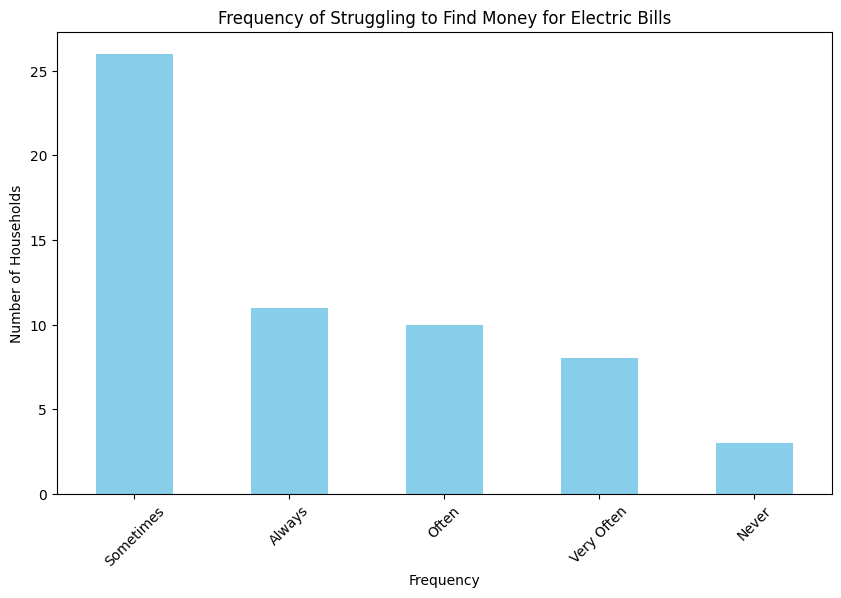

In [109]:
# 7b. Bar chart for struggle frequency
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Use the struggle_counts defined in the previous cell
struggle_counts.plot(kind='bar', color='skyblue')
plt.title("Frequency of Struggling to Find Money for Electric Bills")
plt.ylabel("Number of Households")
plt.xlabel("Frequency")
plt.xticks(rotation=45)
plt.show()

###8. Fail to pay the bill

a. How many households struggle to pay the bill always, very often, often, sometimes, and never?



```
.value_counts()
```


In [110]:
# 8a. Count failure frequency
column_name_fail = "Choose among the following: [How often do you fail to pay the monthly electric bill?]"
fail_counts = final_sample_df[column_name_fail].value_counts()
print(fail_counts)

Choose among the following: [How often do you fail to pay the monthly electric bill?]
Sometimes     31
Never         12
Often          9
Very Often     4
Always         2
Name: count, dtype: int64


b. Make a bar chart

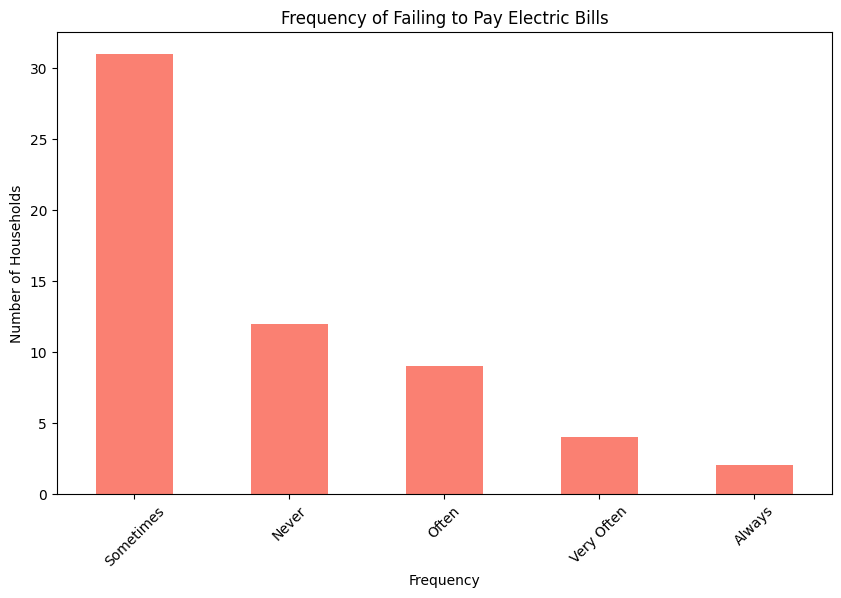

In [111]:
# 8b. Bar chart for failure frequency
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Use the fail_counts defined in the previous cell
fail_counts.plot(kind='bar', color='salmon')
plt.title("Frequency of Failing to Pay Electric Bills")
plt.ylabel("Number of Households")
plt.xlabel("Frequency")
plt.xticks(rotation=45)
plt.show()

###9. You now may use SQL, or Python, whichever is more comfortable.

if you will use SQL, make sure to reconnect to the database THAT IS already in our directory. Careful with the spelling.


a. Count how many households have each of the essential appliances.

1. TV
2. Refrigerator
3. Rice Cooker
4. Washing Machine

<br>

also count how many households got the luxury of having these appliances.

1. Electric Water Dispenser
2. Air Conditioner

In [112]:
# 9a. Appliance Counting
import pandas as pd

appliances = ["TV", "Refrigerator", "Rice Cooker", "Washing Machine", "Electric Water Dispenser", "Air Conditioner"]
appliance_stats = {}

for app in appliances:
    count = final_sample_df["Please tick if you own these appliances (choose all possible)"].str.contains(app, na=False).sum()
    appliance_stats[app] = count

app_df = pd.DataFrame(list(appliance_stats.items()), columns=["Appliance", "Count"])
print(app_df)

                  Appliance  Count
0                        TV     55
1              Refrigerator     42
2               Rice Cooker     33
3           Washing Machine     51
4  Electric Water Dispenser      8
5           Air Conditioner     22


###10. Remember the With_Students table? Now get the number of the students in low income households who has at least a laptop or desktop computer.

In [113]:
# 10. Students with Laptop/Desktop in Low Income
tech_students = final_sample_df[
    (final_sample_df["Are there students in your household?"] == "Yes") &
    (final_sample_df["Do they use any of the following? (choose as many)"].str.contains("Laptop|Desktop Computer", na=False))
]

print(f"Number of low-income households where students have a Laptop or Desktop: {len(tech_students)}")

Number of low-income households where students have a Laptop or Desktop: 43
